# **Environmental Variable Acquisition: Worldclim Download**

## *Developed by Kelly T. Bocanegra-González at the Bedoya Lab (NYBG), May 2026.*

This notebook corresponds to the first stage of environmental data acquisition for Podostemaceae niche modelling analyses and focuses exclusively on downloading, organizing, and preparing bioclimatic variables from WorldClim (https://www.worldclim.org/data/index.html).

Subsequent notebooks will cover additional environmental datasets, including:

- Digital Elevation Models (DEM) for terrain and river network analyses.

- Hydrological and topographic datasets from LSDtopotools.

- Soil and substrate-related layers from databases such as ISRIC SoilGrids.

- Raster and vector data organization for reproducible workflows.

## **1. BIO1–BIO19 from WorldClim**

Codes: | BIO1     | Annual Mean Temperature             |
| BIO2     | Mean Diurnal Range                  |
| BIO3     | Isothermality                       |
| BIO4     | Temperature Seasonality             |
| BIO5     | Max Temperature of Warmest Month    |
| BIO6     | Min Temperature of Coldest Month    |
| BIO7     | Temperature Annual Range            |
| BIO8     | Mean Temperature of Wettest Quarter |
| BIO9     | Mean Temperature of Driest Quarter  |
| BIO10    | Mean Temperature of Warmest Quarter |
| BIO11    | Mean Temperature of Coldest Quarter |
| BIO12    | Annual Precipitation                |
| BIO13    | Precipitation of Wettest Month      |
| BIO14    | Precipitation of Driest Month       |
| BIO15    | Precipitation Seasonality           |
| BIO16    | Precipitation of Wettest Quarter    |
| BIO17    | Precipitation of Driest Quarter     |
| BIO18    | Precipitation of Warmest Quarter    |
| BIO19    | Precipitation of Coldest Quarter    |

In [ ]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required packages
!pip install rasterio geopandas -q

In [ ]:
# Create directories

import os

base_dir = "/content/drive/MyDrive/Podostemaceae/Niche"

os.makedirs(f"{base_dir}/01_data_raw/worldclim", exist_ok=True)
os.makedirs(f"{base_dir}/02_data_processed/climate", exist_ok=True)

print("Directories created.")

In [ ]:
# Download WorldClim BIO1–BIO19
# Resolution: 30 seconds (~1 km)

import urllib.request

url = "https://geodata.ucdavis.edu/climate/worldclim/2_1/base/wc2.1_30s_bio.zip"

output_zip = (
    f"{base_dir}/01_data_raw/worldclim/"
    "wc2.1_30s_bio.zip"
)

urllib.request.urlretrieve(url, output_zip)

print("Download completed.")

In [ ]:
# Unzip BIO1–BIO19 layers

import zipfile

zip_path = (
    f"{base_dir}/01_data_raw/worldclim/"
    "wc2.1_30s_bio.zip"
)

extract_path = (
    f"{base_dir}/01_data_raw/worldclim/"
)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("BIO layers extracted.")

In [ ]:
# Create cropped climate directory

os.makedirs(
    f"{base_dir}/02_data_processed/climate/neotropics",
    exist_ok=True
)

In [1]:
# Crop BIO1–BIO19 to Neotropics or your area of interest
# Test: Visualize cropped BIO1

In [ ]:
# Test: Check raster consistency across BIO layers

import rasterio
import pandas as pd

raster_info = []

for path in cropped_files:

    with rasterio.open(path) as src:

        raster_info.append({
           "file": os.path.basename(path),
            "width": src.width,
           "height": src.height,
           "crs": str(src.crs),
            "resolution": src.res,
            "dtype": src.dtypes[0]
        })

raster_df = pd.DataFrame(raster_info)

raster_df

## **2. Add Podostemaceae dataset**

In [ ]:
# Load Podostemaceae occurrence dataset

import pandas as pd

occ_path = (
    f"{base_dir}/04_results/"
    "Podostemaceae_basins_neotropics.csv"
)

df_occ = pd.read_csv(occ_path)

print(df_occ.shape)

df_occ.head()

In [ ]:
# Convert occurrences to GeoDataFrame

import geopandas as gpd
from shapely.geometry import Point

gdf_occ = gpd.GeoDataFrame(
    df_occ,
    geometry=gpd.points_from_xy(
        df_occ["Longitude"],
        df_occ["Latitude"]
    ),
    crs="EPSG:4326"
)

print(gdf_occ.shape)

gdf_occ.head()

## **3. Extract BIO1-BIO19 for each occurrency**

In [ ]:
# Extract BIO1–BIO19 values for occurrences
import glob
import rasterio
import numpy as np
import os

# Copy GeoDataFrame
gdf_env = gdf_occ.copy()

# Raster files
cropped_files = sorted(
    glob.glob(
        f"{base_dir}/02_data_processed/climate/neotropics/*.tif"
    )
)

#for raster_path in cropped_files:

    # Variable name
   var_name = (
        os.path.basename(raster_path)
        .replace(".tif", "")
        .replace("wc2.1_30s_", "")
    )

    print(f"Extracting {var_name}")

    with rasterio.open(raster_path) as src:

        coords = [
            (x, y)
            for x, y in zip(
                gdf_env.geometry.x,
                gdf_env.geometry.y
            )
        ]

        values = [
            val[0]
            for val in src.sample(coords)
        ]

        # Replace nodata values
        values = [
            np.nan if v == src.nodata else v
            for v in values
        ]

        gdf_env[var_name] = values

print("Environmental extraction completed.")

In [ ]:
# Preview environmental matrix

gdf_env.head()

In [ ]:
# Save environmental occurrence matrix

output_csv = (
    f"{base_dir}/04_results/"
    "Podostemaceae_environmental_matrix.csv"
)

gdf_env.drop(columns="geometry").to_csv(
    output_csv,
    index=False
)

print("Environmental matrix saved.")
print(output_csv)

## **4. Select BIO variables**

In [ ]:
# Load previously saved environmental matrix

env_matrix_path = (
    f"{base_dir}/04_results/"
    "Podostemaceae_environmental_matrix.csv"
)

gdf_env = pd.read_csv(env_matrix_path)

print(gdf_env.shape)

gdf_env.head()

(3500, 40)


,Species,Country,Department_Province,Locality,Latitude,Longitude,Elevation,River,Subbasin,Basin,...,bio_18,bio_19,bio_2,bio_3,bio_4,bio_5,bio_6,bio_7,bio_8,bio_9
0,NaN,Brazil,Pará,"Nova Mocajuba, rio Caeté, aprox. 3,1 km ao oés...",-1.288750,-46.910367,NaN,NaN,NaN,NaN,...,96.0,670.0,9.166666,79.710144,47.934601,32.299999,20.799999,11.500000,25.799999,26.716667
1,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,2.730772,-53.924988,NaN,NaN,NaN,NaN,...,214.0,780.0,9.483334,81.054138,50.915836,32.299999,20.600000,11.699999,25.549999,26.383333
2,Mourera aspera,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.928194,-51.832722,311.0,NaN,NaN,NaN,...,532.0,293.0,12.416667,61.468651,300.796906,29.799999,9.600000,20.199999,23.733334,17.683334
3,Apinagia richardiana,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.931139,-51.838444,310.0,NaN,NaN,NaN,...,534.0,294.0,12.425000,61.815918,298.733124,29.700001,9.600000,20.100000,23.633333,17.666668
4,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,3.913025,-54.261642,NaN,NaN,NaN,NaN,...,263.0,703.0,8.975000,79.424789,53.983353,32.299999,21.000000,11.299999,25.666666,26.700001


In [ ]:
# Select BIO variables only

bio_cols = [
    col for col in gdf_env.columns
    if col.startswith("bio_")
]

bio_df = gdf_env[bio_cols]

print(bio_df.shape)

bio_df.head()

(3500, 19)


,bio_1,bio_10,bio_11,bio_12,bio_13,bio_14,bio_15,bio_16,bio_17,bio_18,bio_19,bio_2,bio_3,bio_4,bio_5,bio_6,bio_7,bio_8,bio_9
0,26.174999,26.883333,25.799999,2338.0,449.0,13.0,77.783241,1178.0,61.0,96.0,670.0,9.166666,79.710144,47.934601,32.299999,20.799999,11.500000,25.799999,26.716667
1,25.733334,26.383333,25.083334,2428.0,352.0,52.0,49.365227,968.0,214.0,214.0,780.0,9.483334,81.054138,50.915836,32.299999,20.600000,11.699999,25.549999,26.383333
2,20.333334,23.733334,16.466667,1480.0,198.0,66.0,37.058201,532.0,250.0,532.0,293.0,12.416667,61.468651,300.796906,29.799999,9.600000,20.199999,23.733334,17.683334
3,20.262501,23.633333,16.416666,1485.0,199.0,67.0,37.173721,534.0,251.0,534.0,294.0,12.425000,61.815918,298.733124,29.700001,9.600000,20.100000,23.633333,17.666668
4,25.912500,26.700001,25.400000,2480.0,375.0,78.0,44.651707,950.0,263.0,263.0,703.0,8.975000,79.424789,53.983353,32.299999,21.000000,11.299999,25.666666,26.700001


In [ ]:
# Select BIO variables

bio_cols = [
    col for col in gdf_env.columns
    if col.startswith("bio_")
]

bio_df = gdf_env[bio_cols]


# Correlation matrix

corr_matrix = bio_df.corr(method="pearson")

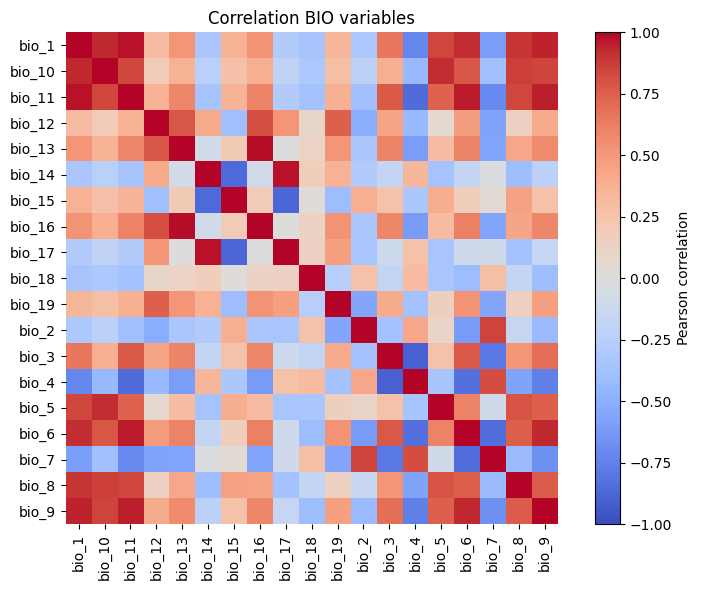

Figure saved:
/content/drive/MyDrive/Podostemaceae/Niche/05_figures/BIO_correlation_heatmap.png


In [ ]:
# Plot correlation heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

ax = plt.gca()

im = ax.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="none"
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.colorbar(im, ax=ax, label="Pearson correlation")

plt.xticks(
    range(len(bio_cols)),
    bio_cols,
    rotation=90
)

plt.yticks(
    range(len(bio_cols)),
    bio_cols
)

plt.title("Correlation BIO variables")

plt.tight_layout()

output_fig = (
    f"{base_dir}/05_figures/"
    "BIO_correlation_heatmap.png"
)

plt.savefig(
    output_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(output_fig)

In [ ]:
# Identify highly correlated variable pairs
# |r| >= 0.85 #commonly use in niche modelling


import pandas as pd
import numpy as np

# Absolute correlation matrix
corr_abs = corr_matrix.abs()

# Keep upper triangle only
upper = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

# Extract highly correlated pairs
high_corr_pairs = []

for col in upper.columns:

    for row in upper.index:

        value = upper.loc[row, col]

        if pd.notnull(value) and value >= 0.85:

            high_corr_pairs.append({
                "Variable_1": row,
                "Variable_2": col,
                "Pearson_r": round(value, 3)
            })

# Convert to dataframe
high_corr_df = pd.DataFrame(high_corr_pairs)

# Sort by correlation strength
high_corr_df = high_corr_df.sort_values(
    by="Pearson_r",
    ascending=False
)

high_corr_df.reset_index(drop=True, inplace=True)

high_corr_df

,Variable_1,Variable_2,Pearson_r
0,bio_13,bio_16,0.981
1,bio_14,bio_17,0.976
2,bio_1,bio_11,0.975
3,bio_11,bio_6,0.956
4,bio_11,bio_9,0.946
5,bio_1,bio_9,0.940
6,bio_6,bio_9,0.935
7,bio_1,bio_10,0.934
8,bio_1,bio_6,0.920
9,bio_10,bio_5,0.918


In [ ]:
# @title
# Save highly correlated variable pairs

output_csv = (
    f"{base_dir}/04_results/"
    "highly_correlated_BIO_pairs.csv"
)

high_corr_df.to_csv(
    output_csv,
    index=False
)

print("File saved:")
print(output_csv)

NameError: name 'base_dir' is not defined

- Variable selection

In [ ]:
# Remove non-selected BIO variables

# Variables retained
selected_bios = [
    "bio_1",
    "bio_4",
    "bio_5",
    "bio_12",
    "bio_13",
    "bio_14"
]

# Variables removed
remove_bios = [
    "bio_2",
    "bio_3",
    "bio_6",
    "bio_7",
    "bio_8",
    "bio_9",
    "bio_10",
    "bio_11",
    "bio_15",
    "bio_16",
    "bio_17",
    "bio_18",
    "bio_19"
]

# Remove variables
gdf_env_selected = gdf_env.drop(
    columns=remove_bios
)

print("Variables removed:")
print(remove_bios)

print("\nVariables retained:")
print(selected_bios)

Variables removed:
['bio_2', 'bio_3', 'bio_6', 'bio_7', 'bio_8', 'bio_9', 'bio_10', 'bio_11', 'bio_15', 'bio_16', 'bio_17', 'bio_18', 'bio_19']

Variables retained:
['bio_1', 'bio_4', 'bio_5', 'bio_12', 'bio_13', 'bio_14']


In [ ]:
# Save final selected environmental matrix

output_csv = (
    f"{base_dir}/04_results/"
    "Podostemaceae_environmental_matrix_bio_selected.csv"
)

gdf_env_selected.drop(
    columns="geometry",
    errors="ignore"
).to_csv(
    output_csv,
    index=False
)

print("Final environmental matrix saved:")
print(output_csv)

Final environmental matrix saved:
/content/drive/MyDrive/Podostemaceae/Niche/04_results/Podostemaceae_environmental_matrix_bio_selected.csv


**Here start PCA and charts**